# Prepare datasets for model training and testing

In [ ]:
# import necessary libraries
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

Setting up local imports of custom python functions

In [ ]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/vidit/projects/Polymer-Glass-Transition-Temperature-Predictor


In [3]:
figs_dir = PROJECT_ROOT / "figs" 

# 1. Data Processing
## Reading data
First we read data for SMILES notation and corresponding log(Tg) value for all 902 polymers

In [4]:
input_data_path = PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_all.csv'
df_input = pd.read_csv(input_data_path)
print("Data-frame shape", df_input.shape)
df_input.head()

Data-frame shape (902, 11)


,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N


In [5]:
smiles_column = 'SMILES_clean' # column with SMILES notation strings
target_column = ['logTg'] # column with target variable value

## Adding physics-based descriptors
* Free volume proxy (using van der Waals volume)
* Chain flexibility (number of rotatable bonds)
* Aromatic content (number of aromatic rings)
* Polarity (TPSA / dipole moment proxy)
* Hydrogen bond donor/acceptor count
* Molecular weight (exact or monomer-based)

I created a custom function that use RDKit on the backend to create the above-described features.

In [6]:
from rdkit.Chem import Descriptors, rdMolDescriptors, MolFromSmiles

def compute_descriptors(smiles):
    """Compute molecular descriptors for a given SMILES string.

    Args:
        smiles (str): The SMILES representation of the molecule.

    Returns:
        descriptors (dict): A dictionary containing the computed molecular descriptors.
            keys include:
                - 'Moleculer Weight': Molecular Weight. 
                - 'Proxy for Free Volume': Proxy for free volume.
                - 'Rotatable Bonds': Number of Rotatable Bonds.
                - 'Aromatic Rings': Number of Aromatic Rings.
                - 'Topological Polar Surface Area': Topological Polar Surface Area.
                - 'H-Bond Donors': Number of Hydrogen Bond Donors.
                - 'H-Bond Acceptors': Number of Hydrogen Bond Acceptors
    """
    # Compute molecular descriptors
    mol = MolFromSmiles(smiles)
    # Check if the molecule was successfully created
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")

    # Compute molecular descriptors
    descriptors = {
        'Moleculer Weight': Descriptors.MolWt(mol),
        'Proxy for Free Volume': rdMolDescriptors.CalcExactMolWt(mol) / rdMolDescriptors.CalcNumHeavyAtoms(mol),
        'Rotatable Bonds':  Descriptors.NumRotatableBonds(mol),
        'Aromatic Rings': rdMolDescriptors.CalcNumAromaticRings(mol),
        'Topological Polar Surface Area': Descriptors.TPSA(mol),
        'H-Bond Donors': rdMolDescriptors.CalcNumHBD(mol),
        'H-Bond Acceptors': rdMolDescriptors.CalcNumHBA(mol)
    }

    return descriptors

In [7]:
# data-frame with molecule-level descriptor data
descriptors_df = pd.DataFrame(
    list(df_input[smiles_column].apply(compute_descriptors))
)
print("Descriptors data-frame shape", descriptors_df.shape)
descriptors_df.head()

Descriptors data-frame shape (902, 7)


,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
0,88.537,17.601596,1,0,0.00,0,0
1,71.079,14.207423,1,0,43.09,1,1
2,153.181,13.916271,4,0,50.09,0,3
3,186.104,15.502533,4,0,26.30,0,2
4,111.100,13.879004,2,0,50.09,0,3


In [8]:
n_descriptors = descriptors_df.shape[1]
print("Number of descriptors per polymer:", n_descriptors)

Number of descriptors per polymer: 7


In [9]:
descriptor_list = descriptors_df.columns.tolist()
descriptor_list

['Moleculer Weight',
 'Proxy for Free Volume',
 'Rotatable Bonds',
 'Aromatic Rings',
 'Topological Polar Surface Area',
 'H-Bond Donors',
 'H-Bond Acceptors']

adding descriptors data-frame to the one containing SMILES notation and log(Tg) values

In [10]:
df_input_w_features = pd.concat(
    [df_input, descriptors_df],
    axis=1
)
print("Final data-frame shape containing all data", df_input_w_features.shape)
df_input_w_features.head()

Final data-frame shape containing all data (902, 18)


,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl,88.537,17.601596,1,0,0.00,0,0
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O,71.079,14.207423,1,0,43.09,1,1
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC,153.181,13.916271,4,0,50.09,0,3
3,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F,186.104,15.502533,4,0,26.30,0,2
4,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N,111.100,13.879004,2,0,50.09,0,3


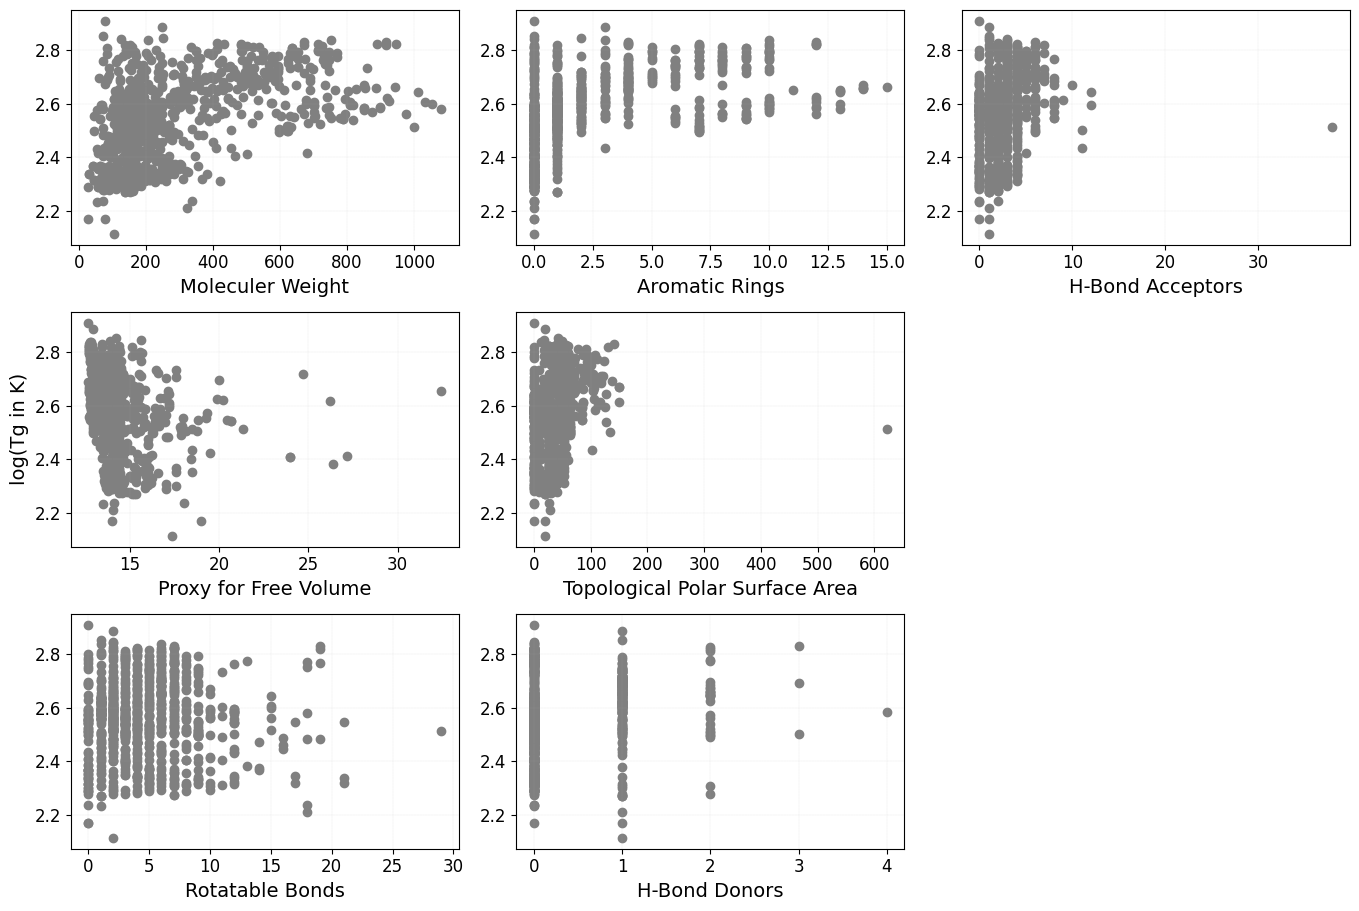

In [22]:
# Plot correlation between each feature and target variable
# Set figure size in inches (width, height)
fig, ax = plt.subplots(3, 3, figsize=(13.7, 9.21))  # 348mm x 234mm
plt_n_ = 3
for i, feat_ in enumerate(descriptor_list):
    ax[i%plt_n_][int(i/plt_n_)].scatter(
        df_input_w_features[feat_],
        df_input_w_features[target_column],
        color='gray'
    )
    # Set y-label
    if (i % plt_n_ == 1) & (int(i/plt_n_) == 0):
        ax[i%plt_n_][int(i/plt_n_)].set_ylabel("log(Tg in K)", fontsize=14)
    # Set x-label
    ax[i%plt_n_][int(i/plt_n_)].set_xlabel(feat_, fontsize=14)
    # Set grid
    ax[i%plt_n_][int(i/plt_n_)].grid(True, which='both', linestyle='--', linewidth=0.1)
    # Set tick parameters
    ax[i%plt_n_][int(i/plt_n_)].tick_params(axis='both', which='major', labelsize=12)
    
ax[1][2].set_visible(False)
ax[2][2].set_visible(False)
plt.tight_layout()
# Save as EPS
plt.savefig(figs_dir / 'correlation_log_Tg_physical_descriptors.eps', format='eps', bbox_inches='tight')
plt.show()
plt.close()

In [12]:
# saving all data with smiles notation and descriptor values
df_input_w_features.to_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'Tg_vs_SMILES_plus_descriptors_all.csv',
    index=False
)

## Splitting training & testing datasets
Now we prepare data-set to be provided to neural network for model training

In [13]:
# get data-frame with training data IDs
train_df = pd.read_csv(
    PROJECT_ROOT / 'data' / 'raw' / 'data_902_original_15desc_logTg_train.csv'
)

In [14]:
# filter input table with IDs within training set
df_smiles_train = df_input_w_features[
    df_input_w_features['ID'].isin(train_df['Index'])
].reset_index(drop=True)

print("Training data-frame w/ SMILES notation", df_smiles_train.shape)

Training data-frame w/ SMILES notation (683, 18)


In [15]:
df_smiles_train.head()

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
0,0,PPD_007,2.7077,T,A,chloroprene,C=CC(=C)Cl,PubChemPy,C=CC(=C)Cl,chloroprene,C=CC(=C)Cl,88.537,17.601596,1,0,0.00,0,0
1,1,PPD_008,2.8520,T,A,acrylamide,C=CC(=O)N,PubChemPy,C=CC(=O)N,acrylamide,C=CC(N)=O,71.079,14.207423,1,0,43.09,1,1
2,2,PPD_010,2.8177,T,A,2-cyanobutyl acrylate,CCC(COC(=O)C=C)C#N,ChemAxon,CCC(COC(=O)C=C)C#N,2-cyanobutyl acrylate,C=CC(=O)OCC(C#N)CC,153.181,13.916271,4,0,50.09,0,3
3,4,PPD_019,2.7552,T,A,cyanomethyl acrylate,C=CC(=O)OCC#N,PubChemPy,C=CC(=O)OCC#N,cyanomethyl acrylate,C=CC(=O)OCC#N,111.100,13.879004,2,0,50.09,0,3
4,5,PPD_029,2.7687,T,A,octadecyl acrylate,CCCCCCCCCCCCCCCCCCOC(=O)C=C,PubChemPy,CCCCCCCCCCCCCCCCCCOC(=O)C=C,octadecyl acrylate,C=CC(=O)OCCCCCCCCCCCCCCCCCC,324.549,14.100123,18,0,26.30,0,2


In [16]:
# saving training data-table with smiles notation and descriptor values
df_smiles_train.to_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'training_data.csv',
    index=False
)

In [17]:
# using rest of them for independent testing of the model performance
df_smiles_test = df_input_w_features[
    ~df_input_w_features['ID'].isin(train_df['Index'])
].reset_index(drop=True)

print("Training data-frame w/ SMILES notation", df_smiles_test.shape)

Training data-frame w/ SMILES notation (219, 18)


In [18]:
df_smiles_test.head()

,Unnamed: 0,ID,logTg,Series,Ref,name_raw,SMILES_raw,SMI_generator,SMILES,name,SMILES_clean,Moleculer Weight,Proxy for Free Volume,Rotatable Bonds,Aromatic Rings,Topological Polar Surface Area,H-Bond Donors,H-Bond Acceptors
0,3,PPD_013,2.7178,P,A,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(C(F)F)(F)F,PubChemPy,C=CC(=O)OCC(C(F)F)(F)F,"2,2,3,3-tetrafluoropropyl acrylate",C=CC(=O)OCC(F)(F)C(F)F,186.104,15.502533,4,0,26.30,0,2
1,8,PPD_043,2.7854,P,A,1-(tert-butyl)ethene,CC(C)(C)C=C,ChemAxon,CC(C)(C)C=C,1-(tert-butyl)ethene,C=CC(C)(C)C,84.162,14.015650,0,0,0.00,0,0
2,23,PPD_123,2.8103,P,A,dimethyl itaconate,COC(=O)CC(=C)C(=O)OC,PubChemPy,COC(=O)CC(=C)C(=O)OC,dimethyl itaconate,C=C(CC(=O)OC)C(=O)OC,158.153,14.368901,3,0,52.60,0,4
3,38,PPD_214,2.6868,P,A,vinyl ethyl ketone,CCC(=O)C=C,PubChemPy,CCC(=O)C=C,vinyl ethyl ketone,C=CC(=O)CC,84.118,14.009586,2,0,17.07,0,1
4,41,PPD_217,2.7317,P,A,ethyl vinyl thioether,CCSC=C,ChemAxon,CCSC=C,ethyl vinyl thioether,C=CSCC,88.175,17.606934,2,0,0.00,0,1


In [19]:
# saving test data-table with smiles notation and descriptor values
df_smiles_test.to_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'test_data.csv',
    index=False
)